In [20]:
%cd /home/dani/projects/neuroscience

/home/dani/projects/neuroscience


In [47]:
import torch
import torch.nn as nn
import torchsde
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

In [ ]:
class LinearControlSDE(torch.nn.Module):
    noise_type = 'diagonal'
    sde_type = 'ito'
    
    def __init__(self, A, B, control_input: callable, sigma=0.1):
        super().__init__()
        self.A = A
        self.B = B
        self.sigma = sigma
        self.state_size = A.shape[0]
        self.control_size = B.shape[1]
        self.control_input = control_input
        
    def f(self, t, x):
        """Drift function: Ax + Bu"""
        # Get control input at time t
        u = self.control_input(t, x)
        return torch.matmul(x, self.A.T) + torch.matmul(u, self.B.T)
    
    def g(self, t, x):
        """Diffusion function: σ"""
        batch_size = x.shape[0]
        state_diffusion = self.sigma * torch.ones(batch_size, self.state_size)
        return state_diffusion

In [23]:
m, k, c = 1.0, 1.0, 0.5
A = torch.tensor([[0.0, 1.0],[-k/m, -c/m]])
B = torch.tensor([[0.0], [1.0/m]])

Define the (finite-horizon) controllability Gramian for (T>0):
$$
W_c(T)=\int_0^T e^{A\tau} B B^T e^{A^T\tau} d\tau.
$$

In [24]:
def compute_gramian(A, B, T, n_steps=200):
    times = torch.linspace(0, T, n_steps + 1, dtype=A.dtype, device=A.device)
    
    At = A.unsqueeze(0) * times.view(-1, 1, 1)
    Et = torch.vmap(torch.matrix_exp)(At)
    
    BBT = B @ B.T
    Mt = Et @ BBT @ Et.transpose(-2, -1)
    
    # Apply trapezoidal weights: 0.5 for first and last, 1.0 for middle
    weights = torch.ones(n_steps + 1, dtype=A.dtype, device=A.device)
    weights[0], weights[-1] = 0.5, 0.5
    
    Wc = torch.sum(Mt * weights.view(-1, 1, 1), dim=0)
    Wc *= (T / n_steps)
    return Wc

**Kalman (controllability) criterion:** the pair $(A,B)$ is controllable iff the $n\times nm$ controllability matrix
$$
\mathcal{C} = \big[B|AB|A^2B|\dots|A^{n-1}B\big]
$$
has rank $n$.

In this case, the control is given by
$$
u(s)=B^T e^{A^T(T-s)} W_c(T)^{-1} \big(x_{\text{target}}-e^{AT}x_0\big)
$$
with the minimum cost:
$$
J(u) = \frac{1}{2} \int_0^T \|u(t)\|^2 dt = \frac{1}{2} d^{\top}W_{c}(T)^{-1}d,\qquad d:=x_{\text{target}}-e^{AT}x_{0}
$$

In [66]:
class OptimalRoute(nn.Module):
    def __init__(self, A, B, x_target, T, n_steps=200, regularize=1e-9):
        super().__init__()
        self.x_target = x_target.reshape(1, -1)
        self.A = A
        self.B = B
        self.T = T
        self.m_exp = torch.matrix_exp(A * T)

        Wc = compute_gramian(A, B, T, n_steps=n_steps)
        Wc_reg = Wc + regularize * torch.eye(A.shape[0])
        self.Wc_inv = torch.inverse(Wc_reg)

    def forward(self, t, x):
        s = self.T - t
        term = torch.matrix_exp(self.A.T * s)
        u = ((self.x_target - x @ self.m_exp.T) @ self.Wc_inv.T) @ term.T @ self.B
        return u

In [87]:
m, k, c = 1.0, 1.0, 0.5
A = torch.tensor([[0.0, 1.0],[-k/m, -c/m]])
B = torch.tensor([[0.0], [1.0/m]])
t_span = [0.0, 20.0] # Time Span
ts = torch.linspace(t_span[0], t_span[1], 400)

# Initial condition: [position, velocity]
x0 = torch.tensor([[2.0, 0.0]])
x_target = torch.tensor([1., 1.])

# Initialize spring-mass-damper system
control_input = lambda t, x: torch.zeros(x.shape[0], B.shape[1]) # No control
sde = LinearControlSDE(A, B, control_input=control_input, sigma=0.0)

# Simulate multiple trajectories
xs = torchsde.sdeint(sde, x0, ts, method="euler", dt_min=1e-2)

In [88]:
ts_np = ts.detach().numpy()
xs_np = xs.squeeze().detach().numpy()

margin = 0.5
x_min, x_max = xs_np[:, 0].min()-margin, xs_np[:, 0].max()+margin
y_min, y_max = xs_np[:, 1].min()-margin, xs_np[:, 1].max()+margin

X1, X2 = np.meshgrid(np.linspace(x_min, x_max, 20), np.linspace(y_min, y_max, 20))
Anp = A.detach().numpy()
U = Anp[0, 0] * X1 + Anp[0, 1] * X2
V = Anp[1, 0] * X1 + Anp[1, 1] * X2

fig, ax = plt.subplots(figsize=(8, 6))
ax.streamplot(X1, X2, U, V, color='lightgray', density=1.5, linewidth=0.5, arrowsize=1)
line, = ax.plot([], [], '--')  # 'o-' shows points and lines
dot, = ax.plot([], [], 'o', markersize=8, color='k')
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()

def update(frame):
    line.set_data(xs_np[:frame+1, 0], xs_np[:frame+1, 1])
    dot.set_data([xs_np[frame, 0]], [xs_np[frame, 1]])
    return line, dot

anim = FuncAnimation(fig, update, frames=len(ts_np), blit=True)
anim.save('images/animation_v1.gif', writer=PillowWriter(fps=20))
plt.close()

In [89]:
torch.manual_seed(1234)

# Initial condition: [position, velocity]
x0 = torch.tensor([[2.0, 0.0]])
x_target = torch.tensor([1., 1.])

# Time span
t_span = [0.0, 20.0]
ts = torch.linspace(t_span[0], t_span[1], 400)

# Initialize spring-mass-damper system
control_input = OptimalRoute(A, B, x_target, T=t_span[1])
sde = LinearControlSDE(A, B, control_input=control_input, sigma=0.0)

# Simulate multiple trajectories
xs = torchsde.sdeint(sde, x0, ts, method="euler", dt_min=1e-2)

In [91]:
ts_np = ts.detach().numpy()
xs_np = xs.squeeze().detach().numpy()
u = torch.tensor(np.array([control_input(ti, yi) for ti, yi in zip(ts, xs)]))

margin = 0.5
x_min, x_max = xs_np[:, 0].min()-margin, xs_np[:, 0].max()+margin
y_min, y_max = xs_np[:, 1].min()-margin, xs_np[:, 1].max()+margin

X1, X2 = np.meshgrid(np.linspace(x_min, x_max, 20), np.linspace(y_min, y_max, 20))
Anp = A.detach().numpy()
U = Anp[0, 0] * X1 + Anp[0, 1] * X2
V = Anp[1, 0] * X1 + Anp[1, 1] * X2

fig, ax = plt.subplots(figsize=(8, 6))
ax.streamplot(X1, X2, U, V, color='lightgray', density=1.5, linewidth=0.5, arrowsize=1)
line, = ax.plot([], [], '--')  # 'o-' shows points and lines
dot, = ax.plot([], [], 'o', markersize=8, color='k')
ax.scatter(x0[:,0].numpy(), x0[:,1].numpy(), s=50, c="g", zorder=5, label='Initial condition')
ax.scatter(x_target[0].numpy(), x_target[1].numpy(), s=50, c="r", zorder=5, label='target condition')
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

x1_traj = xs_np[:, 0]
x2_traj = xs_np[:, 1]

U_traj, V_traj = (torch.matmul(u, B.T).T).detach().numpy().squeeze()
quiver = ax.quiver(x1_traj[0], x2_traj[0], 0, 0, 
                   scale=2, scale_units='xy', angles='xy',
                   width=0.003, alpha=0.6, headwidth=3, color='blue', label="Optimal control")

ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.legend(loc='upper right')

def update(frame):
    line.set_data(xs_np[:frame+1, 0], xs_np[:frame+1, 1])
    dot.set_data([xs_np[frame, 0]], [xs_np[frame, 1]])

    # Update quiver directions only for the part of the trajectory shown so far
    quiver.set_offsets([[x1_traj[frame], x2_traj[frame]]])
    quiver.set_UVC([U_traj[frame]], [V_traj[frame]])
    return line, dot, quiver

anim = FuncAnimation(fig, update, frames=len(ts_np), blit=True)
anim.save('images/animation_v2.gif', writer=PillowWriter(fps=20))
plt.close()

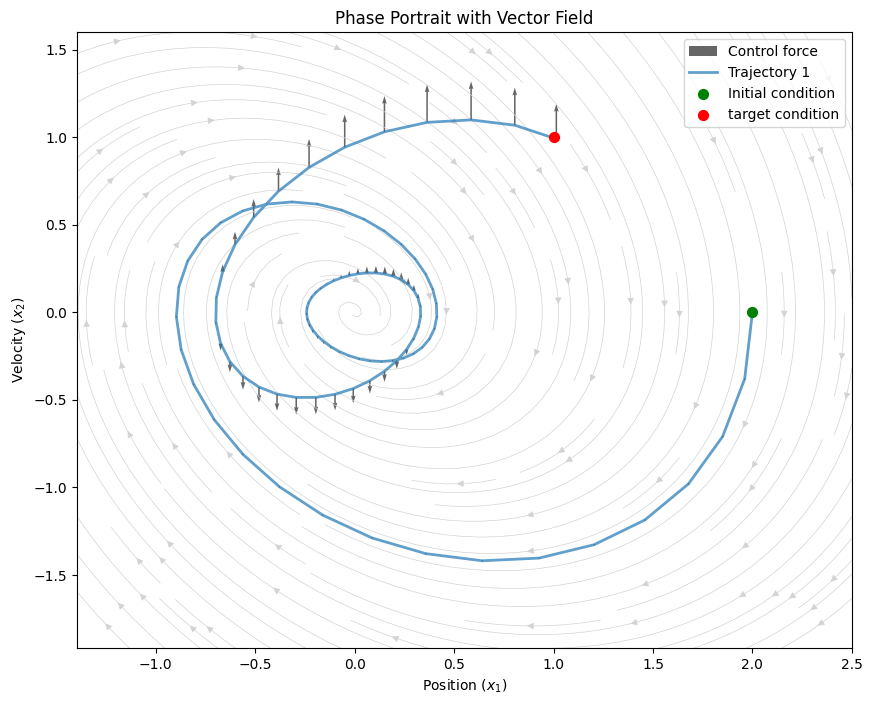

In [75]:
ts_np = ts.detach().numpy()
xs_np = xs.squeeze().detach().numpy()
u = torch.tensor(np.array([control_input(ti, yi) for ti, yi in zip(ts, xs)]))

# Phase portrait
plt.figure(figsize=(10, 8))

# Create a grid for the vector field
margin = 0.5
x_min, x_max = xs_np[:, 0].min()-margin, xs_np[:, 0].max()+margin
y_min, y_max = xs_np[:, 1].min()-margin, xs_np[:, 1].max()+margin

X1, X2 = np.meshgrid(np.linspace(x_min, x_max, 20), np.linspace(y_min, y_max, 20))

# Compute the vector field
Anp = A.detach().cpu().numpy()
U = Anp[0, 0] * X1 + Anp[0, 1] * X2
V = Anp[1, 0] * X1 + Anp[1, 1] * X2

# Plot streamlines
plt.streamplot(X1, X2, U, V, color='lightgray', density=1.5, linewidth=0.5, arrowsize=1)

# Plot trajectories
x1_traj = xs_np[:, 0]
x2_traj = xs_np[:, 1]

U_traj, V_traj = (torch.matmul(u, B.T).T).detach().numpy()

# Plot ALL vectors along trajectory
plt.quiver(x1_traj, x2_traj, U_traj, V_traj,
            scale=5, scale_units='xy', angles='xy',
            width=0.002, alpha=0.6, headwidth=3, label="Control force")

plt.plot(xs_np[:, 0], xs_np[:, 1], alpha=0.7, linewidth=2, label=f'Trajectory {1}')

plt.scatter(x0[:,0].numpy(), x0[:,1].numpy(), s=50, c="g", zorder=5, label='Initial condition')
plt.scatter(x_target[0].numpy(), x_target[1].numpy(), s=50, c="r", zorder=5, label='target condition')
plt.xlabel('Position ($x_1$)')
plt.ylabel('Velocity ($x_2$)')
plt.title('Phase Portrait with Vector Field')
plt.legend(loc='upper right')
plt.savefig('phase_portrait_sde.png', dpi=150, bbox_inches='tight')
plt.show()

In [42]:
# # Plot results
# fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# # Position
# axes[0].set_title(f'Spring-Mass-Damper System (m={m}, k={k}, c={c})')
# for i in range(num_trajectories):
#     axes[0].plot(ts_np, ys_np[:, i, 0], alpha=0.7, label=f'Trajectory {i+1}')
# axes[0].set_ylabel('Position (x₁)')
# axes[0].grid(True)
# axes[0].legend()

# # Velocity
# for i in range(num_trajectories):
#     axes[1].plot(ts_np, ys_np[:, i, 1], alpha=0.7, label=f'Trajectory {i+1}')
# axes[1].set_xlabel('Time (t)')
# axes[1].set_ylabel('Velocity (x₂)')
# axes[1].grid(True)
# axes[1].legend()

# plt.tight_layout()
# plt.savefig('spring_mass_damper_sde.png', dpi=150, bbox_inches='tight')
# plt.show()
